# How to use timeline

This tutorial demonstrates how to use timeline.

## What is a timeline?

Timeline allows to have properties of some features evolving over time.
For example, a camera feature, a lightbox feature can move according to a trajectory.
Also, the flux of a surface source can vary over time.
The timeline is activated at the simulation level, and then the features that have timeline data
will be taken into account during the simulation compute.

## Prerequisites

### Perform imports

In [1]:
import os
from pathlib import Path

from ansys.speos.core import Project, Speos, launcher
from ansys.speos.core.component import LightBox
from ansys.speos.core.generic.version_checker import server_version_checker
from ansys.speos.core.kernel.client import default_docker_channel
from ansys.speos.core.sensor import SensorCamera
from ansys.speos.core.simulation import SimulationInverse
from ansys.speos.core.source import SourceSurface


### Define constants

The constants help ensure consistency and avoid repetition throughout the example.

In [2]:
HOSTNAME = "localhost"
GRPC_PORT = 50098  # Be sure the Speos GRPC Server has been started on this port.
USE_DOCKER = True  # Set to False if you're running this example locally as a Notebook.

## Model Setup

### Load assets
The assets used to run this example are available in the
[PySpeos repository](https://github.com/ansys/pyspeos/) on GitHub.

> **Note:** Make sure you
> have downloaded simulation assets and set ``assets_data_path``
> to point to the assets folder.

In [3]:
if USE_DOCKER:  # Running on the remote server.
    assets_data_path = Path("/app") / "assets"
else:
    assets_data_path = Path("/path/to/your/download/assets/directory")

### Connect to the RPC Server
This Python client connects to a server where the Speos engine
is running as a service. In this example, the server and
client are the same machine. The launch_local_speos_rpc_method can
be used to start a local instance of the service..

In [4]:
if USE_DOCKER:
    speos = Speos(channel=default_docker_channel(port=GRPC_PORT))
else:
    speos = launcher.launch_local_speos_rpc_server(port=GRPC_PORT)

/home/runner/work/pyspeos/pyspeos/.venv/lib/python3.14/site-packages/ansys/tools/common/cyberchannel.py:188: UserWarning: Starting gRPC client without TLS on localhost:50098. This is INSECURE. Consider using a secure connection.
  warn(f"Starting gRPC client without TLS on {target}. This is INSECURE. Consider using a secure connection.")


### Create a project from file

Create a project by loading a .speos file.
This project will be then modified to see how timeline can be activated on different features,
and how it impacts the simulation results.

In [5]:
p = Project(speos=speos, path=assets_data_path / "TimelineExample.speos" / "TimelineExample.speos")
p.preview()

EmbeddableWidget(value='<iframe srcdoc="<!doctype html>\n<html lang=&quot;en&quot;>\n  <head>\n    <meta chars…

## Timeline activation and results

### Timeline not activated on the simulation
Let's just retrieve the simulation feature and compute it without activating timeline,
to have a baseline result to compare with.

In [6]:
simu_feat: SimulationInverse = p.find(name=".*", name_regex=True, feature_type=SimulationInverse)[0]
simu_feat.stop_condition_passes_number = 5
simu_feat.commit()

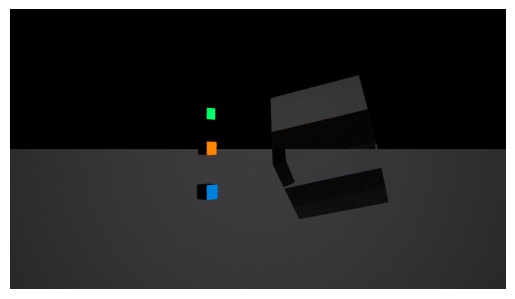

In [7]:
# Compute and display the result.
simu_feat.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=simu_feat, result_name="Inverse.1.Camera.1.Irradiance.xmp")

### Timeline activated on the simulation but no timeline data in the features
Now, let's activate timeline on the simulation feature,
but without having any timeline data in the features.
We should get the same result as before.

In [8]:
simu_feat.timeline = True
simu_feat.commit()

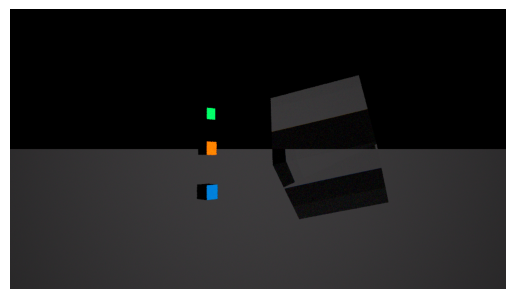

In [9]:
# Compute and display the result.
simu_feat.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=simu_feat, result_name="Inverse.1.Camera.1.Exposure.xmp")

### Timeline on camera feature
Let's activate timeline on the camera feature by setting a trajectory file.

In [10]:
camera_feat: SensorCamera = p.find(name=".*", name_regex=True, feature_type=SensorCamera)[0]
camera_feat.photometric.trajectory_file_uri = (
    assets_data_path / "TimelineExample.speos" / "CameraTrajectory.json"
)
camera_feat.commit()

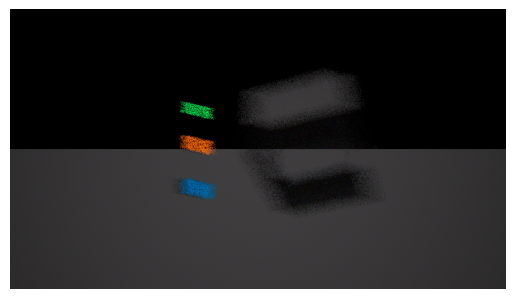

In [11]:
# Compute and display the result.
simu_feat.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=simu_feat, result_name="Inverse.1.Camera.1.Exposure.xmp")

In [12]:
# Deactivate timeline for camera feature (not to pollute next results)
camera_feat.photometric.trajectory_file_uri = ""
camera_feat.commit()

### Timeline on surface source features
Let's activate timeline on the surface source features by setting a flux variation file.
Same json but different relative lag for each source feature (0, 33, 66).

In [13]:
i = 0
for source_feat in p.find(name=".*", name_regex=True, feature_type=SourceSurface):
    source_feat: SourceSurface
    source_feat.flux_variation_file_uri = (
        assets_data_path / "TimelineExample.speos" / "flux_variation.json"
    )
    source_feat.relative_lag = i * 100 / 3
    source_feat.commit()
    i = i + 1

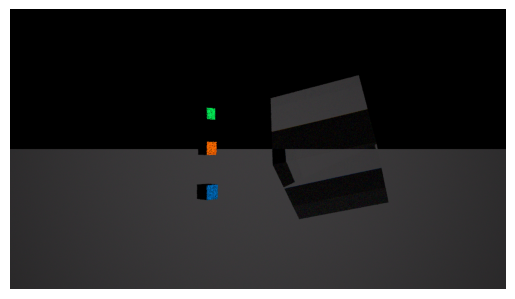

In [14]:
# Compute and display the result.
simu_feat.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=simu_feat, result_name="Inverse.1.Camera.1.Exposure.xmp")

In [15]:
# Deactivate timeline for surface source features (not to pollute next results)
for source_feat in p.find(name=".*", name_regex=True, feature_type=SourceSurface):
    source_feat: SourceSurface
    source_feat.flux_variation_file_uri = ""
    source_feat.commit()

### Timeline on light box feature
Let's activate timeline on the light box feature by setting a trajectory file.

In [16]:
lb_feat: LightBox = p.find(name=".*", name_regex=True, feature_type=LightBox)[0]
lb_feat.trajectory_file_uri = assets_data_path / "TimelineExample.speos" / "LightBoxTrajectory.json"
lb_feat.commit()

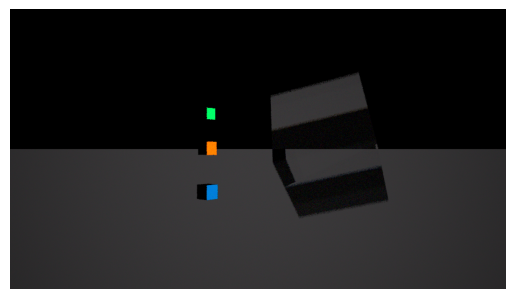

In [17]:
# Compute and display the result.
simu_feat.compute_CPU()
# Method available only on Windows OS or with Speos 2026 R1.2 or higher,
# which supports opening XMP results as images regardless of the OS.
if os.name == "nt" or server_version_checker.is_version_supported(2026, 1, 2):
    from ansys.speos.core.workflow.open_result import open_result_image

    open_result_image(simulation_feature=simu_feat, result_name="Inverse.1.Camera.1.Exposure.xmp")

In [18]:
# Deactivate timeline for light box feature
lb_feat.trajectory_file_uri = ""
lb_feat.commit()